# PFGS Multi-Objective Optimization

Combining VAE and PFGS

## Setup

In [14]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import mlflow

PROJECT_ROOT = Path("/Users/elenipsaromatis/Documents/mol-vae")
sys.path.insert(0, str(PROJECT_ROOT))

import train as train_mod
from data import MAX_LENGTH, build_dataloaders_multitask
from model import VAE

EXPERIMENT_NAME = "mol-vae"
MLRUNS_URI = (PROJECT_ROOT / "notebooks" / "mlruns").resolve().as_uri()
mlflow.set_tracking_uri(MLRUNS_URI)
client = mlflow.tracking.MlflowClient()

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)
print("tracking uri:", MLRUNS_URI)

device: mps
tracking uri: file:///Users/elenipsaromatis/Documents/mol-vae/notebooks/mlruns


## Config

`MODE = "train"` retrains. `MODE = "load"` uses `LOAD_RUN_ID`.

In [15]:
MODE = "load"   # "train" or "load"
LOAD_RUN_ID = "604b520490aa4dfc8cd1961054095be4"  
BATCH_SIZE = 64

## Train or Load

Training uses the hyperparameters fixed in `train.py`. It logs to MLflow and saves a checkpoint, then this cell picks up the run that was just created.

In [16]:
if MODE == "train":
    train_mod.train()
    exp = client.get_experiment_by_name(EXPERIMENT_NAME)
    latest = client.search_runs(
        [exp.experiment_id],
        order_by=["attributes.start_time DESC"],
        max_results=1,
    )
    run_id = latest[0].info.run_id
elif MODE == "load":
    run_id = LOAD_RUN_ID
else:
    raise ValueError("MODE must be 'train' or 'load'")

run = client.get_run(run_id)
print("run_id:", run_id)
print("run name:", run.data.tags.get("mlflow.runName"))
print("status:", run.info.status)

run_id: 604b520490aa4dfc8cd1961054095be4
run name: vae_solubility_ld50_604b5204
status: FINISHED


## Rebuild the trained model from the run checkpoint


In [17]:
def build_model_from_state_dict(state_dict, seq_len, device):
    vocab_size = state_dict["encoder.conv.0.weight"].shape[1]
    hidden_dim = state_dict["encoder.fc.weight"].shape[0]
    latent_dim = state_dict["encoder.fc_mu.weight"].shape[0]
    n_layers = state_dict["decoder.fc_z.weight"].shape[0] // hidden_dim
    prop_hidden_size = state_dict["reg_predictor.net.0.weight"].shape[0]

    model = VAE(
        vocab_size=vocab_size,
        seq_len=seq_len,
        hidden_dim=hidden_dim,
        latent_dim=latent_dim,
        n_layers=n_layers,
        prop_hidden_size=prop_hidden_size,
    ).to(device)
    model.load_state_dict(state_dict)
    model.eval()
    print(
        f"loaded: vocab={vocab_size} hidden={hidden_dim} latent={latent_dim} "
        f"layers={n_layers} prop_hidden={prop_hidden_size}"
    )
    return model


ckpt_path = (
    run.data.tags.get("eval_checkpoint")
    or run.data.tags.get("best_checkpoint")
    or run.data.tags.get("final_checkpoint")
    or run.data.tags.get("checkpoint")
)

if ckpt_path is None or not Path(ckpt_path).exists():
    ckpt_dir = PROJECT_ROOT / "checkpoints"
    run_short = run_id[:8]
    candidates = [
        ckpt_dir / f"vae_solubility_ld50_{run_short}_best.pth",
        ckpt_dir / f"vae_solubility_ld50_{run_short}_final.pth",
        ckpt_dir / f"vae_solubility_{run_short}_best.pth",
        ckpt_dir / f"vae_solubility_{run_short}_final.pth",
        ckpt_dir / f"vae_solubility_{run_short}.pth",
    ]
    ckpt_path = next((str(c) for c in candidates if c.exists()), None)
    if ckpt_path is None:
        raise FileNotFoundError(
            f"No checkpoint for run {run_short}. Looked at tags and {candidates}."
        )

state_dict = torch.load(ckpt_path, map_location=device)
model = build_model_from_state_dict(state_dict, MAX_LENGTH, device)
print("checkpoint:", ckpt_path)

loaded: vocab=34 hidden=512 latent=100 layers=3 prop_hidden=32
checkpoint: /Users/elenipsaromatis/Documents/mol-vae/checkpoints/vae_solubility_ld50_604b5204_best.pth


## Data and loss hyperparameters


In [18]:
from train import GAMMA, KL_FREE_BITS, BETA_MAX
gamma = GAMMA
kl_free_bits = KL_FREE_BITS
final_beta = BETA_MAX

In [19]:
(
    train_loader,
    valid_loader,
    test_loader,
    vocab_size,
    char2idx,
    idx2char,
    train_labels,
    sol_mean,
    sol_std,
    ld50_mean,
    ld50_std,
) = build_dataloaders_multitask(batch_size=BATCH_SIZE)

Found local copy...
Loading...
Done!
100%|██████████| 9982/9982 [00:00<00:00, 17286.70it/s]
Found local copy...
Loading...
Done!


[split] sizes train/valid/test: 1607/112/357
[split] vocab_size: 34
[target] solubility mean/std: -2.169/2.070
[target] LD50 mean/std: 2.268/0.872


## Loss Curves

In [20]:
from train import evaluate_loss
from evaluate import evaluate, evaluate_regression, evaluate_test

test_total, test_recon, test_kl, test_reg, test_ld50 = evaluate_loss(
    model=model,
    loader=test_loader,
    beta=final_beta,
    gamma=gamma,
    device=device,
    kl_free_bits=kl_free_bits,
)

test_sol_metrics = evaluate_regression(
    model, test_loader, device, sol_mean, sol_std, head="reg_predictor", label_idx=0
)
test_ld50_metrics = evaluate_regression(
    model, test_loader, device, ld50_mean, ld50_std, head="ld50_predictor", label_idx=1
)

test_exact_acc, test_token_acc, test_validity = evaluate(
    model, test_loader.dataset, vocab_size, device, idx2char
)

print(
    f"test  total={test_total:.4f}  recon={test_recon:.4f}  kl={test_kl:.4f}\n"
    f"      sol_reg={test_reg:.4f}  sol_rmse={test_sol_metrics['rmse']:.4f}  sol_mae={test_sol_metrics['mae']:.4f}\n"
    f"      ld50_reg={test_ld50:.4f}  ld50_rmse={test_ld50_metrics['rmse']:.4f}  ld50_mae={test_ld50_metrics['mae']:.4f}\n"
    f"      recon_acc={test_exact_acc:.3f}  token_acc={test_token_acc:.3f}  validity={test_validity:.3f}"
)

test  total=0.9677  recon=0.7967  kl=184.1701
      sol_reg=0.4075  sol_rmse=1.3241  sol_mae=1.0015
      ld50_reg=1.0003  ld50_rmse=0.8905  ld50_mae=0.5888
      recon_acc=0.000  token_acc=0.752  validity=0.115


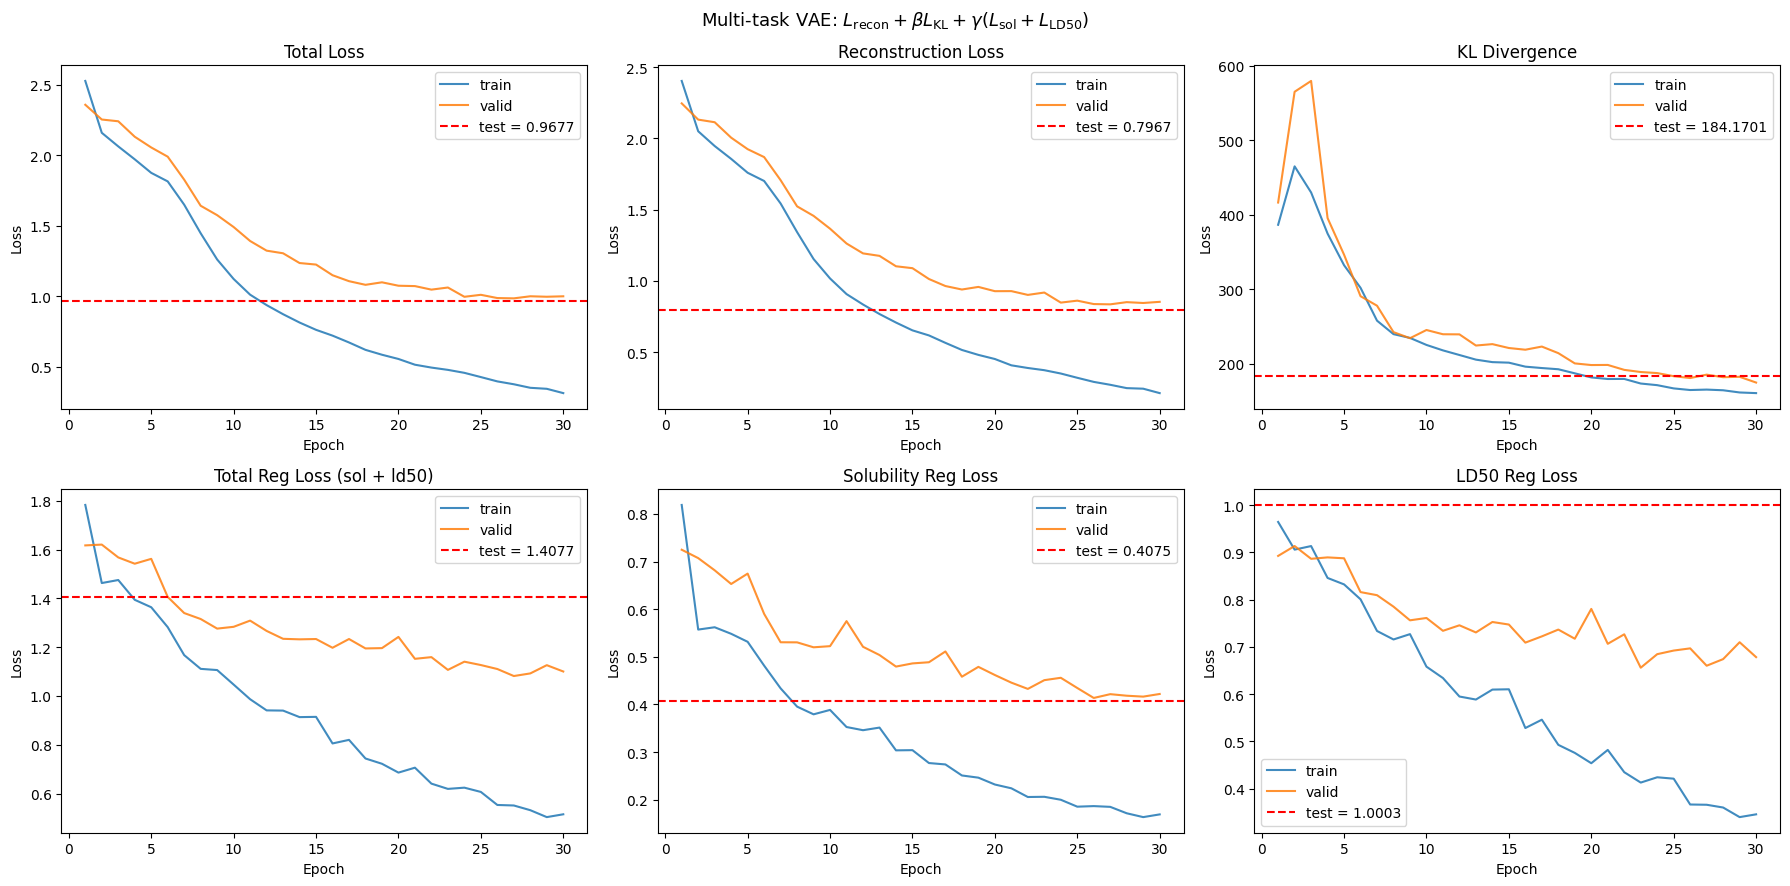

In [21]:
def get_metric(metric_name):
    history = sorted(client.get_metric_history(run_id, metric_name), key=lambda m: m.step)
    return np.array([m.step for m in history]), np.array([m.value for m in history])

epochs, train_total_c = get_metric("train_loss")
_, valid_total_c = get_metric("valid_loss")
_, train_recon_c = get_metric("train_recon")
_, valid_recon_c = get_metric("valid_recon")
_, train_kl_c = get_metric("train_kl")
_, valid_kl_c = get_metric("valid_kl")
_, train_reg_c = get_metric("train_reg_loss")
_, valid_reg_c = get_metric("valid_reg_loss")
_, train_ld50_c = get_metric("train_ld50_loss")
_, valid_ld50_c = get_metric("valid_ld50_loss")

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

panels = [
    ("Total Loss",
     [(train_total_c, "train"), (valid_total_c, "valid")],
     [(test_total, "test", "red")]),
    ("Reconstruction Loss",
     [(train_recon_c, "train"), (valid_recon_c, "valid")],
     [(test_recon, "test", "red")]),
    ("KL Divergence",
     [(train_kl_c, "train"), (valid_kl_c, "valid")],
     [(test_kl, "test", "red")]),
    ("Total Reg Loss (sol + ld50)",
     [(train_reg_c + train_ld50_c, "train"), (valid_reg_c + valid_ld50_c, "valid")],
     [(test_reg + test_ld50, "test", "red")]),
    ("Solubility Reg Loss",
     [(train_reg_c, "train"), (valid_reg_c, "valid")],
     [(test_reg, "test", "red")]),
    ("LD50 Reg Loss",
     [(train_ld50_c, "train"), (valid_ld50_c, "valid")],
     [(test_ld50, "test", "red")]),
]

for ax, (title, series, tests) in zip(axes, panels):
    for values, label in series:
        ax.plot(epochs, values, label=label, alpha=0.85)
    for te, label, color in tests:
        ax.axhline(te, color=color, linestyle="--", linewidth=1.5, label=f"{label} = {te:.4f}")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

fig.suptitle(
    r"Multi-task VAE: $L_{\mathrm{recon}} + \beta L_{\mathrm{KL}}"
    r" + \gamma (L_{\mathrm{sol}} + L_{\mathrm{LD50}})$",
    fontsize=13,
)
plt.tight_layout()
plt.show()